# Plate Color + Lighting Validation (real crops)

**Module:** `plate_color_pipeline` — VN plate background-color classifier (HSV heuristic) + lighting handling.

**Goal of this notebook.** Run the finished `process_plate` pipeline on *real* Vietnamese plate
crops and check that its behaviour matches what we expect before we trust it downstream:

1. **Color distribution** — does the classifier reproduce the ~62% white / 19% yellow / 10% blue / 6% red
   split measured on real crops during data inventory (`docs/research/2026-07-28-dataset-inventory-verified.md`)?
2. **Light-on-dark plates** — are blue/red plates (light text on dark background) classified correctly?
   This is the exact case the research prototype `docs/research/tools/color_check.py` got wrong.
3. **Lighting handling** — what conditions do real crops fall into, and does the OCR-path enhancement
   visibly improve dark / low-contrast / glare crops?

**Crop source.** We don't have the tight `plate_ocr_topkek` crops on disk, so we cut plate crops out of the
labelled **`a1_det`** detection set (`data/processed/a1_det`, YOLO plate boxes, class 0 = 1-row, 1 = 2-row).
We use the **val + test** splits only (never train) — ~1.1k images — so this stays an honest held-out check.

> Note: `a1_det` boxes are looser than topkek's tight crops, so absolute percentages will drift a little
> (more background bleed → slightly more 'white'). We care about the *shape* of the distribution and the
> blue/red behaviour, not exact parity.

## Setup

In [1]:
%matplotlib inline
from __future__ import annotations
import sys, random
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt

# Locate the repo root by walking up until we find the dataset, then make the
# plate_color package importable even if it wasn't pip-installed in this kernel.
root = Path.cwd()
while root != root.parent and not (root / 'data' / 'processed' / 'a1_det').exists():
    root = root.parent
assert (root / 'data' / 'processed' / 'a1_det').exists(), 'could not find data/processed/a1_det'

pkg = root / 'src' / 'ml' / 'plate_color_pipeline'
if str(pkg) not in sys.path:
    sys.path.insert(0, str(pkg))

from plate_color import process_plate
from plate_color.lighting.enhance import enhance
from plate_color.lighting.metrics import classify_lighting

SEED = 3            # same seed as color_check.py for a comparable sample
random.seed(SEED)
np.random.seed(SEED)

A1 = root / 'data' / 'processed' / 'a1_det'
print('repo root:', root)
print('dataset :', A1)

repo root: /Users/ducqhle/Documents/workspace/UIT2026-DoAnCuoiKi
dataset : /Users/ducqhle/Documents/workspace/UIT2026-DoAnCuoiKi/data/processed/a1_det


## Cut plate crops from the detection labels

Each YOLO label line is `class cx cy w h` (all normalised 0..1). We de-normalise, add a small
pad, and cut the plate region out of the image — exactly the kind of crop `PlateDetection.crop`
would hand to `process_plate` in the real pipeline.

In [2]:
def yolo_boxes(label_path: Path, W: int, H: int, pad: float = 0.04):
    """Yield (class_id, x1, y1, x2, y2) pixel boxes from a YOLO label file."""
    if not label_path.exists():
        return
    for line in label_path.read_text().splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        cls, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:5])
        # de-normalise centre/size -> corner pixels, with a little context pad
        px, py = bw * W * pad, bh * H * pad
        x1 = int((cx - bw / 2) * W - px); y1 = int((cy - bh / 2) * H - py)
        x2 = int((cx + bw / 2) * W + px); y2 = int((cy + bh / 2) * H + py)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)
        if x2 - x1 >= 8 and y2 - y1 >= 8:
            yield cls, x1, y1, x2, y2


def iter_crops(splits=('val', 'test'), limit=None):
    """Yield (crop_bgr, layout_class, source_frame_bgr, box) over the chosen splits.

    source_frame_bgr is the full detection image the crop was cut from; box is the
    (x1, y1, x2, y2) pixel plate box inside that frame.
    """
    n = 0
    for split in splits:
        img_dir = A1 / 'images' / split
        lbl_dir = A1 / 'labels' / split
        for img_path in sorted(img_dir.glob('*')):
            if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png'}:
                continue
            im = cv2.imread(str(img_path))
            if im is None:
                continue
            H, W = im.shape[:2]
            lbl = lbl_dir / (img_path.stem + '.txt')
            for cls, x1, y1, x2, y2 in yolo_boxes(lbl, W, H):
                yield im[y1:y2, x1:x2].copy(), cls, im, (x1, y1, x2, y2)
                n += 1
                if limit and n >= limit:
                    return


crops = [(c, cls, frame, box) for c, cls, frame, box in iter_crops(('val', 'test'))]
print(f'cut {len(crops)} plate crops from a1_det val+test')

cut 1313 plate crops from a1_det val+test


## Run the pipeline on every crop

One `process_plate` call per crop gives us the predicted color, its confidence, the lighting
condition, and the enhanced OCR crop. We collect the scalars into a small table.

In [3]:
records = []
enhanced = []   # keep (raw, enhanced, condition, color, source_frame, box) for the montages below
for crop, layout, frame, box in crops:
    a = process_plate(crop)
    records.append({
        'color': a.color,
        'color_conf': round(a.color_conf, 3),
        'lighting': a.lighting,
        'layout': '1-row' if layout == 0 else '2-row',
    })
    enhanced.append((crop, a.crop_for_ocr, a.lighting, a.color, frame, box))

N = len(records)
print(f'processed {N} crops')
records[:5]

processed 1313 crops


[{'color': 'white',
  'color_conf': 0.631,
  'lighting': 'normal',
  'layout': '2-row'},
 {'color': 'white',
  'color_conf': 0.63,
  'lighting': 'normal',
  'layout': '2-row'},
 {'color': 'white',
  'color_conf': 0.92,
  'lighting': 'glare',
  'layout': '2-row'},
 {'color': 'white',
  'color_conf': 0.859,
  'lighting': 'normal',
  'layout': '2-row'},
 {'color': 'white',
  'color_conf': 0.709,
  'lighting': 'normal',
  'layout': '2-row'}]

## 1. Color distribution vs the inventory baseline

Baseline from real topkek crops (599 samples): white 62.1%, yellow 19.2%, blue 9.5%, red 6.2%,
other/unknown 2.5%. We expect the same ordering here; looser crops push a few points toward white.

color       count   ours %  topkek %
white        1210     92.2      62.1
yellow         82      6.2      19.2
blue           13      1.0       9.5
red             8      0.6       6.2
unknown         0      0.0       2.5


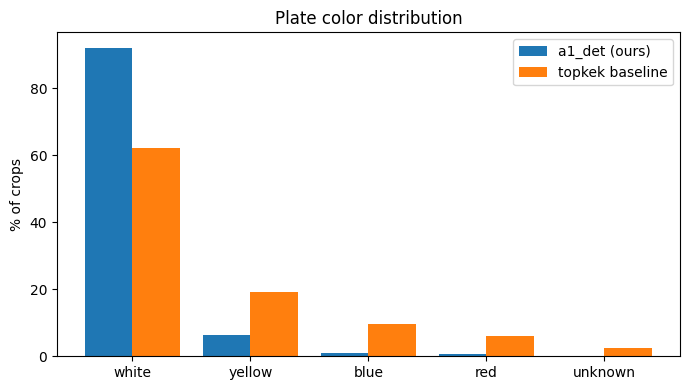

In [4]:
from collections import Counter

order = ['white', 'yellow', 'blue', 'red', 'unknown']
counts = Counter(r['color'] for r in records)
baseline = {'white': 62.1, 'yellow': 19.2, 'blue': 9.5, 'red': 6.2, 'unknown': 2.5}

print(f"{'color':10s} {'count':>6s} {'ours %':>8s} {'topkek %':>9s}")
for c in order:
    pct = 100 * counts.get(c, 0) / N
    print(f'{c:10s} {counts.get(c, 0):6d} {pct:8.1f} {baseline[c]:9.1f}')

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(order))
ours = [100 * counts.get(c, 0) / N for c in order]
base = [baseline[c] for c in order]
ax.bar(x - 0.2, ours, 0.4, label='a1_det (ours)')
ax.bar(x + 0.2, base, 0.4, label='topkek baseline')
ax.set_xticks(x); ax.set_xticklabels(order); ax.set_ylabel('% of crops')
ax.set_title('Plate color distribution'); ax.legend()
plt.tight_layout(); plt.show()

## 2. Sample crops per predicted color

Eyeball check — do the crops the classifier calls `blue` / `red` actually look blue / red?
These are the light-text-on-dark cases the old prototype misread as `white`.

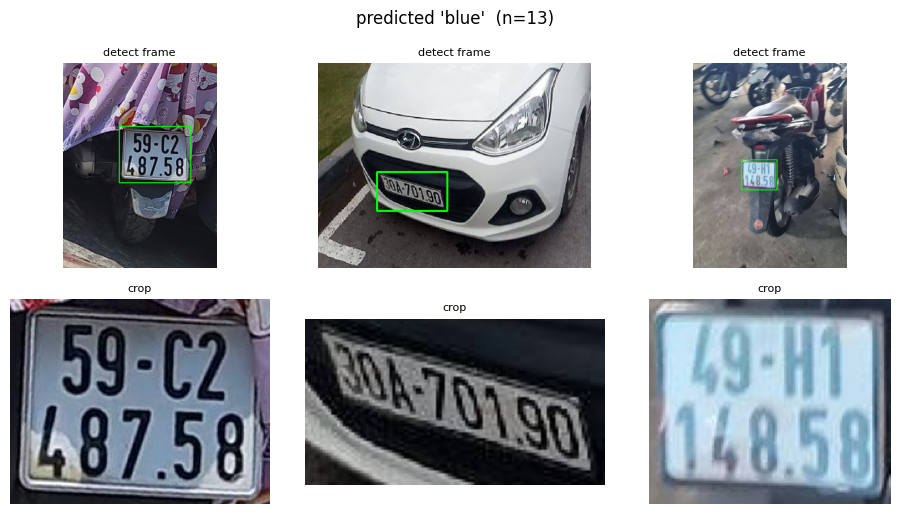

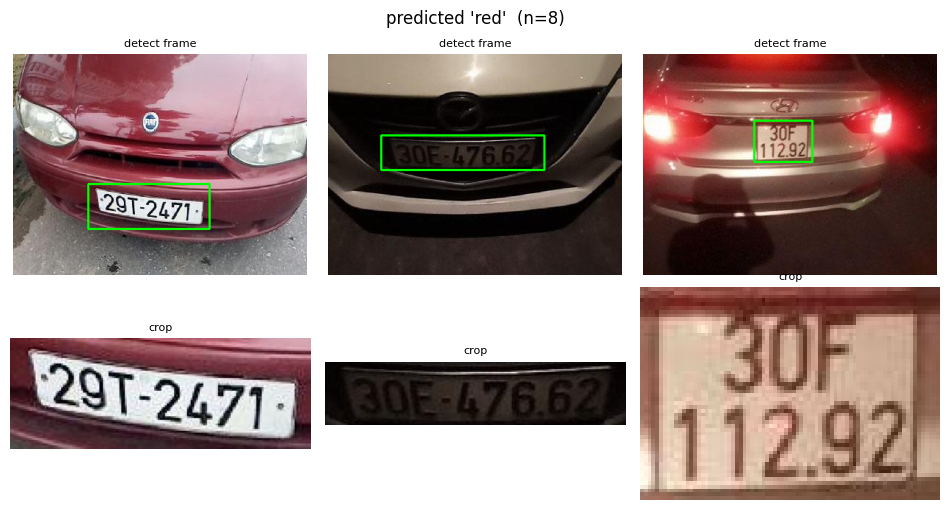

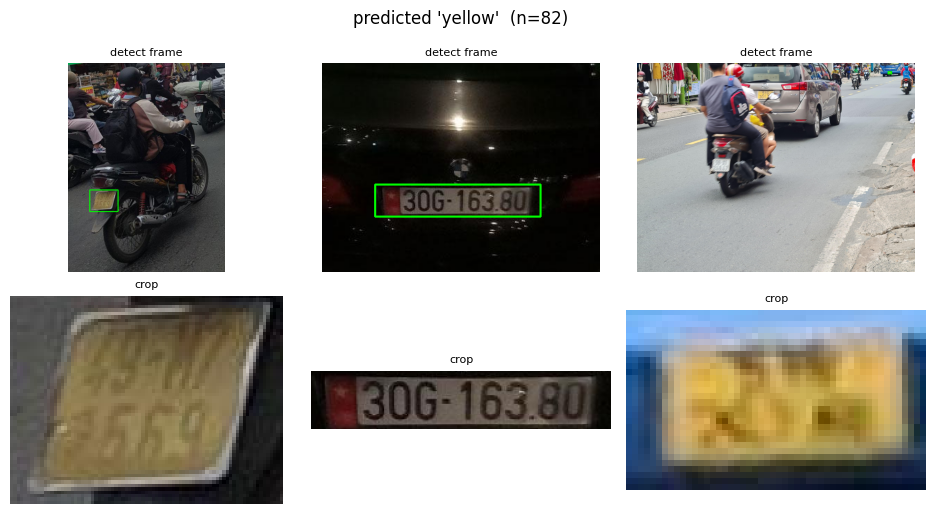

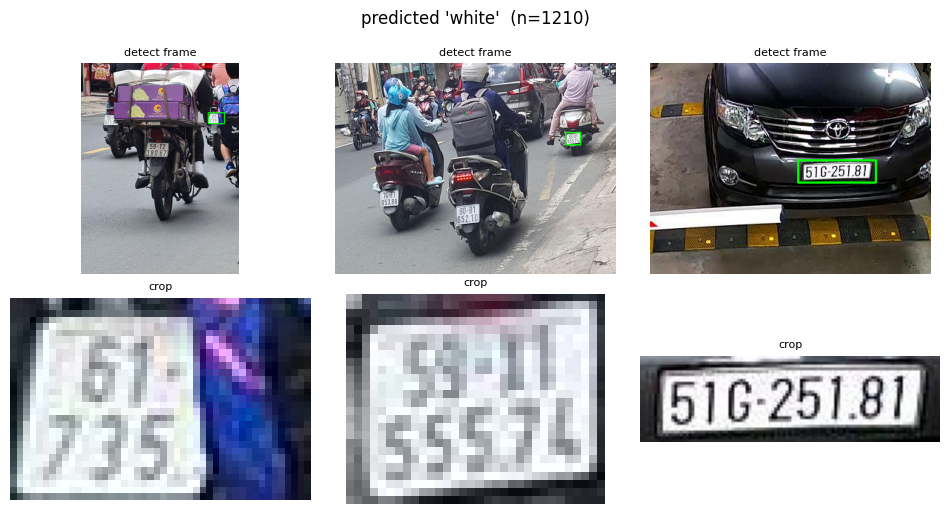

In [5]:
def draw_box(frame, box, color=(0, 255, 0), thick=None):
    """Return an RGB copy of the full frame with the plate box drawn on it."""
    x1, y1, x2, y2 = box
    out = frame.copy()
    t = thick or max(2, round(0.004 * max(frame.shape[:2])))
    cv2.rectangle(out, (x1, y1), (x2, y2), color, t)
    return cv2.cvtColor(out, cv2.COLOR_BGR2RGB)


def show_source_and_crop(items, title, cols=3):
    """items: list of (crop_bgr, source_frame_bgr, box). Top row = full detect frame
    with the plate box drawn; bottom row = the crop fed to process_plate."""
    k = min(cols, len(items))
    if k == 0:
        print('no crops for', title); return
    fig, axes = plt.subplots(2, k, figsize=(3.2 * k, 5.2), squeeze=False)
    fig.suptitle(title)
    for j, (crop, frame, box) in enumerate(items[:k]):
        axes[0, j].imshow(draw_box(frame, box)); axes[0, j].axis('off')
        axes[0, j].set_title('detect frame', fontsize=8)
        axes[1, j].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)); axes[1, j].axis('off')
        axes[1, j].set_title('crop', fontsize=8)
    plt.tight_layout(); plt.show()


by_color = {c: [] for c in order}
for (crop, _, _, color, frame, box) in enhanced:
    by_color[color].append((crop, frame, box))

for c in ['blue', 'red', 'yellow', 'white']:
    pool = by_color[c]
    if not pool:
        print(f'no crops predicted {c}'); continue
    pick = random.sample(pool, min(3, len(pool)))
    show_source_and_crop(pick, f"predicted '{c}'  (n={len(pool)})")

## 3. Lighting conditions on real crops

What lighting buckets does the metrics stage assign, and how often? This tells us whether the
adaptive enhancement branches actually fire on this data or whether most crops are already `normal`.

normal            971   74.0%
glare             321   24.4%
low_light          18    1.4%
overexposed         2    0.2%
low_contrast        1    0.1%


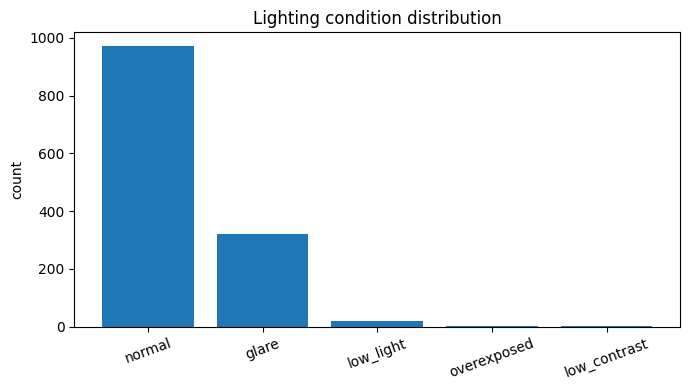

In [6]:
lcounts = Counter(r['lighting'] for r in records)
for cond, n in lcounts.most_common():
    print(f'{cond:14s} {n:6d}  {100 * n / N:5.1f}%')

fig, ax = plt.subplots(figsize=(7, 4))
conds = [c for c, _ in lcounts.most_common()]
ax.bar(conds, [lcounts[c] for c in conds])
ax.set_ylabel('count'); ax.set_title('Lighting condition distribution')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## 4. Before / after lighting enhancement

For each non-`normal` condition we show a few raw crops (top) next to their `crop_for_ocr`
(bottom) — the crop the OCR stage would actually receive. Looking for: dark crops brightened,
low-contrast crops opened up, glare tamed, without the text being destroyed.

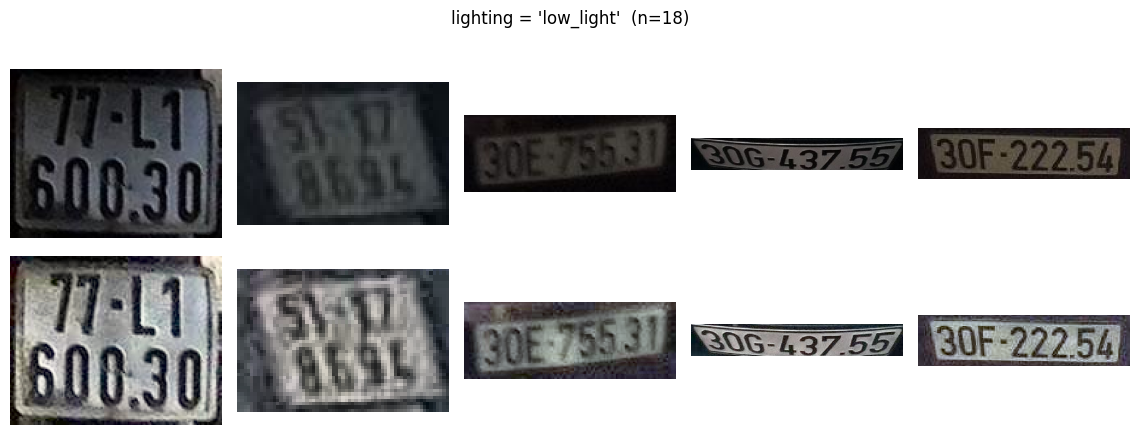

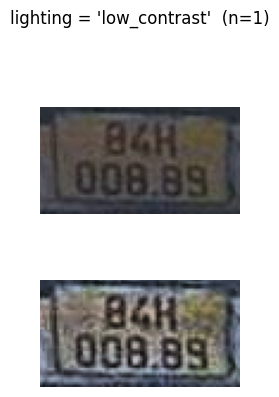

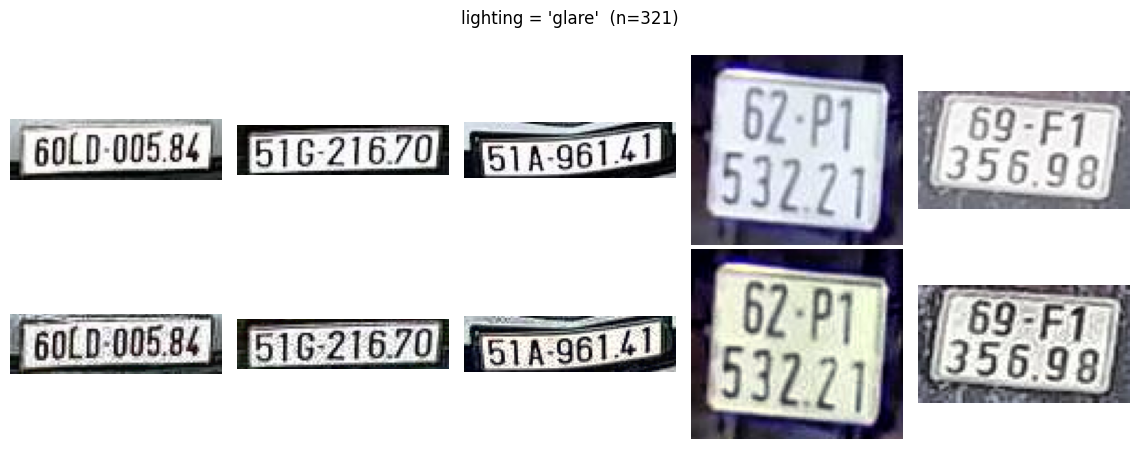

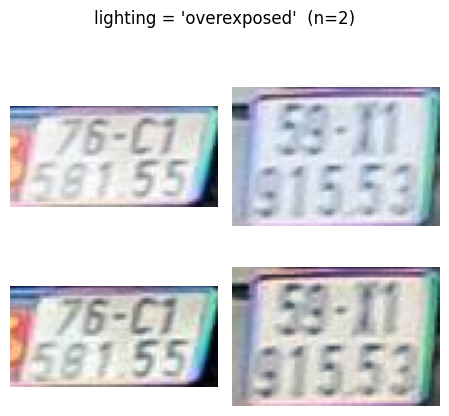

In [7]:
def show_before_after(pairs, title, cols=5):
    k = min(cols, len(pairs))
    if k == 0:
        print('no crops for', title); return
    fig, axes = plt.subplots(2, k, figsize=(2.3 * k, 4.6), squeeze=False)
    fig.suptitle(title)
    for j, (raw, enh) in enumerate(pairs[:k]):
        axes[0, j].imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)); axes[0, j].axis('off')
        axes[1, j].imshow(cv2.cvtColor(enh, cv2.COLOR_BGR2RGB)); axes[1, j].axis('off')
    axes[0, 0].set_ylabel('raw', fontsize=9)
    axes[1, 0].set_ylabel('enhanced', fontsize=9)
    plt.tight_layout(); plt.show()


for cond in ['low_light', 'low_contrast', 'glare', 'overexposed']:
    pairs = [(raw, enh) for (raw, enh, c, *_ ) in enhanced if c == cond]
    if pairs:
        random.shuffle(pairs)
        show_before_after(pairs, f"lighting = '{cond}'  (n={len(pairs)})")

## 5. Export a summary for report chapter 03

Writes the color and lighting distributions to CSV so the numbers in the report table stay in
sync with the code. The `color_conf` column also lets us spot low-confidence (near-`unknown`)
predictions worth hand-verifying.

> For the report's *accuracy* table (not just distribution) we still need a hand-verified label
> set: sample ~200 crops balanced across the 4 colors, correct any wrong predictions by eye, and
> score against that. This notebook produces the sample; the verification is manual.

In [8]:
import csv

out_dir = root / 'docs' / 'report' / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)
csv_path = out_dir / 'plate_color_distribution.csv'

with csv_path.open('w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['metric', 'bucket', 'count', 'percent'])
    for c in order:
        w.writerow(['color', c, counts.get(c, 0), round(100 * counts.get(c, 0) / N, 1)])
    for cond, n in lcounts.most_common():
        w.writerow(['lighting', cond, n, round(100 * n / N, 1)])

print('wrote', csv_path)
print(csv_path.read_text())

wrote /Users/ducqhle/Documents/workspace/UIT2026-DoAnCuoiKi/docs/report/figures/plate_color_distribution.csv
metric,bucket,count,percent
color,white,1210,92.2
color,yellow,82,6.2
color,blue,13,1.0
color,red,8,0.6
color,unknown,0,0.0
lighting,normal,971,74.0
lighting,glare,321,24.4
lighting,low_light,18,1.4
lighting,overexposed,2,0.2
lighting,low_contrast,1,0.1



## Notes & caveats

- **Crop source is looser than topkek.** `a1_det` boxes include more surrounding frame, which
  biases slightly toward `white`; treat absolute percentages as indicative, the ordering as the check.
- **`unknown` is a feature, not a miss.** Motion-blurred / heavily shadowed crops fall below the
  confidence floor by design (`plate_color/color/thresholds.py`) rather than being force-labelled.
- **Thresholds are the tuning surface.** If the distribution or a color grid looks off, adjust
  `plate_color/color/thresholds.py` (hue bands, sat/val cutoffs) or the lighting cutoffs in
  `plate_color/lighting/metrics.py` — no retraining involved.
- **Next:** hand-verify a balanced ~200-crop sample for the report's color-accuracy table.